In [ ]:
import pandas
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [ ]:
data = pandas.read_csv('data_final_datmin.csv')
data

,Nama Hotel,Jarak dari balai kota,Harga dalam semalam,Bintang Hotel,Rating,Jumlah Review,Jumlah Fasilitas
0,Hotel 88 Kedungsari (Kedungdoro) By WH,3.7,276822.0,3,8.6,6000,47
1,Amaris Hotel Embong Malang,3.7,306306.0,2,8.4,5000,30
2,DoubleTree by Hilton Surabaya,0.4,1153350.0,4,8.9,1400,20
3,Deka Hotel Surabaya HR Muhammad,10.0,386978.0,2,8.4,4200,44
4,Hotel 88 Embong Malang By WH,3.7,305846.0,3,8.4,6500,39
...,...,...,...,...,...,...,...
299,Spacious and Nice 2BR at The Via and The Vue A...,10.6,1106072.0,1,9.1,2,11
300,Charisma Residence,10.3,68101.0,2,5.9,5,3
301,RedDoorz @ Siwalankerto Surabaya,8.2,244061.0,1,7.4,30,9
302,Best Choice And Nice Studio Apartment At Grand...,5.7,436309.0,3,9.4,1,2


# Clustering

In [ ]:
data_cluster = data.copy()

var = ['Jarak dari balai kota', 'Bintang Hotel', 'Rating',
       'Jumlah Review', 'Jumlah Fasilitas']
x = data_cluster[var]

In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

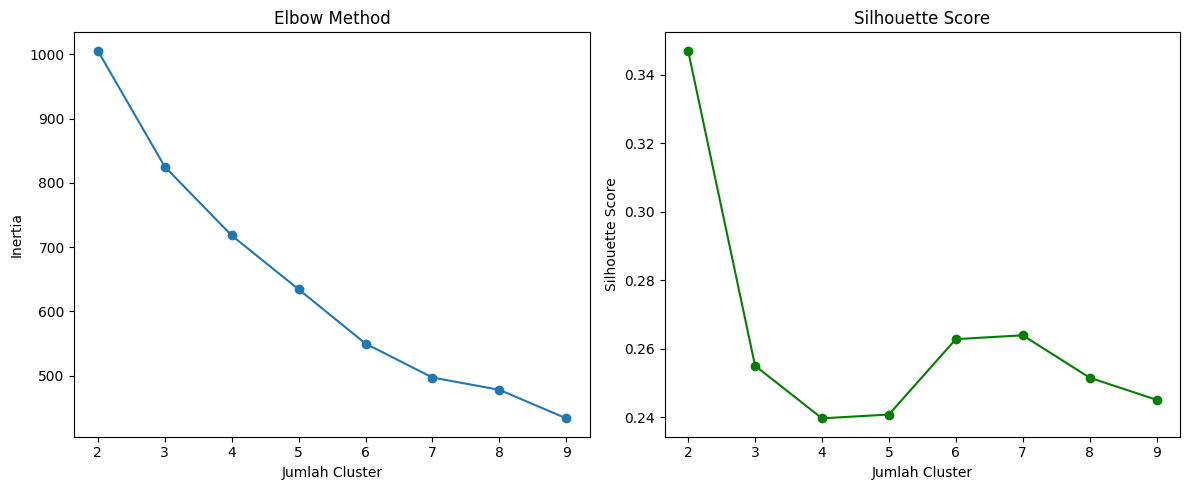

In [ ]:
inertia_values = []
silhouette_scores = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(x_scaled)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(x_scaled, labels))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(2,10), inertia_values, marker='o')
plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia")

plt.subplot(1, 2, 2)
plt.plot(range(2,10), silhouette_scores, marker='o', color='green')
plt.title("Silhouette Score")
plt.xlabel("Jumlah Cluster")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=50)
clusters = kmeans.fit_predict(x_scaled)

In [ ]:
data_cluster['Cluster'] = clusters
data_cluster['Harga dalam semalam'] = data['Harga dalam semalam']

cluster_summary = data_cluster.groupby('Cluster')['Harga dalam semalam'].describe()
print(data_cluster['Cluster'].value_counts())

Cluster
1    137
2     92
0     75
Name: count, dtype: int64


In [ ]:
cluster_0 = data_cluster[data_cluster['Cluster'] == 0]
cluster_1 = data_cluster[data_cluster['Cluster'] == 1]
cluster_2 = data_cluster[data_cluster['Cluster'] == 2]

In [ ]:
cluster_summary

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,75.0,211166.960000,155081.887256,47617.0,119973.0,152838.0,214162.50,770303.0
1,137.0,253713.496350,171704.771866,42975.0,151824.0,194242.0,309917.00,1106072.0
2,92.0,461300.326087,334103.544157,65519.0,262080.0,332802.0,515082.25,1500000.0


In [ ]:
cluster_0

In [ ]:
cluster_1

In [ ]:
cluster_2

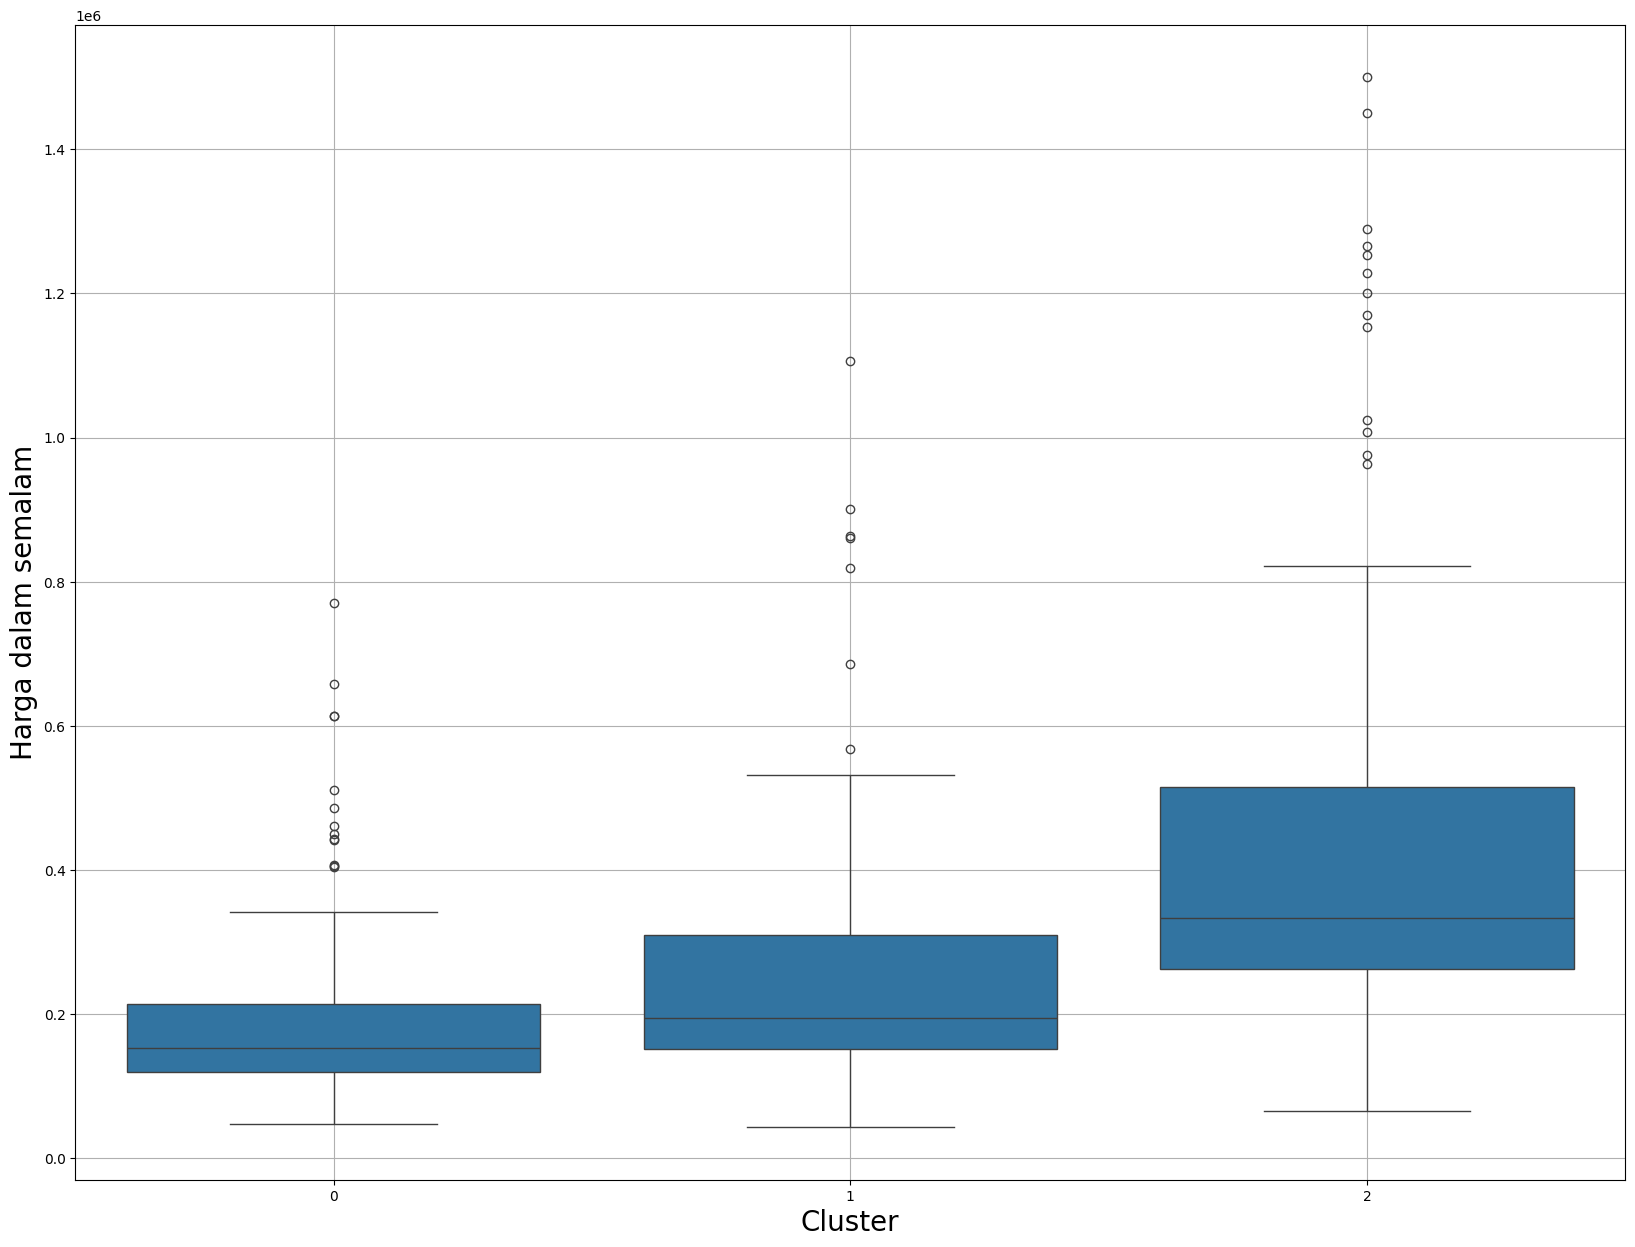

In [ ]:
plt.figure(figsize=(20, 15))
sns.boxplot(x='Cluster', y='Harga dalam semalam', data=data_cluster)
plt.xlabel("Cluster", fontsize=20)
plt.ylabel("Harga dalam semalam", fontsize=20)
plt.grid()
plt.show()

In [ ]:
batas_murah = (cluster_summary.loc[0, '75%'] + cluster_summary.loc[1, '25%']) / 2
batas_menengah = (cluster_summary.loc[1, '75%'] + cluster_summary.loc[2, '25%']) / 2
print(f"Harga hotel yang termasuk dalam golongan murah : Rp.{batas_murah} Kebawah")
print(f"Harga hotel yang termasuk dalam golongan menengah : Rp.{batas_murah} - Rp.{batas_menengah}")
print(f"Harga hotel yang termasuk dalam golongan mahal : Rp.{batas_menengah} Keatas")

Harga hotel yang termasuk dalam golongan murah : Rp.182993.25 Kebawah
Harga hotel yang termasuk dalam golongan menengah : Rp.182993.25 - Rp.285998.5
Harga hotel yang termasuk dalam golongan mahal : Rp.285998.5 Keatas


# Regresi

## Part 1

In [ ]:
data_regresi = data.copy()

var = ['Jarak dari balai kota', 'Bintang Hotel', 'Rating', 'Jumlah Review', 'Jumlah Fasilitas']

x = data_regresi[var]
y = data_regresi['Harga dalam semalam']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_features='sqrt', min_samples_leaf=1)
rf_model.fit(x_train, y_train)

y_pred = rf_model.predict(x_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.4f}')

RMSE: 149812.98
R²: 0.5599


c:\Users\ryanz\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Part 2

In [ ]:
data_regresi = data.copy()

data_regresi['harga_per_bintang'] = data_regresi['Harga dalam semalam'] / data_regresi['Bintang Hotel']
data_regresi['harga_per_fasilitas'] = data_regresi['Harga dalam semalam'] / data_regresi['Jumlah Fasilitas']
data_regresi['fasilitas_per_bintang'] = data_regresi['Jumlah Fasilitas'] / data_regresi['Bintang Hotel']
data_regresi['rating_x_review'] = data_regresi['Rating'] * data_regresi['Jumlah Review']

var = ['Jarak dari balai kota', 'Bintang Hotel', 'Rating', 'Jumlah Review', 'Jumlah Fasilitas',
       'harga_per_bintang', 'harga_per_fasilitas', 'rating_x_review', 'fasilitas_per_bintang']

x = data_regresi[var]
y = data_regresi['Harga dalam semalam']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_features='sqrt', min_samples_leaf=1)
rf_model.fit(x_train, y_train)

y_pred = rf_model.predict(x_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.4f}')

RMSE: 72412.61
R²: 0.8972


c:\Users\ryanz\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
